In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import scienceplots



# 1. Cargar datos

In [9]:
# Path relativo desde notebooks/ hasta data/results/
ruta_excel = "../data/results/similitudes_chunks.xlsx"

sim_df = pd.read_excel(ruta_excel, engine="openpyxl")

# Identificar columnas de categorías (ajusta si es necesario)
subcat_cols = sim_df.columns[3:20]  # <- revisa si son las correctas
print("Columnas de categorías:", subcat_cols.tolist())


Columnas de categorías: ['Ciencias_ambientales_ingenieria', 'Ciencias_espacio', 'Ciencias_fisicas', 'Ciencias_Geografia_oceanografia', 'Ciencias_medicas', 'Ciencias_metereologia', 'Ciencias_naturales', 'Ciencias_polucion_catastrofes_seguridad', 'Ciencias_quimicas', 'Ciencias_tierra', 'Ciencia_Administracion_ciencia_investigacion', 'Ciencia_biologia', 'Ciencia_enfoque_cientifico', 'Ciencia_hidrologia', 'Ciencia_matematicas_estadistica', 'Ciencia_patologia', 'Ciencia_recursos_naturales']


# 2. Filtrar scores mayores a 0.4

In [25]:
# Crear ID único por chunk
sim_df["chunk_uid"] = sim_df["id_doc"].astype(str) + "_" + sim_df["chunk_id"].astype(str)

# Asegurar que las columnas de subcategorías son numéricas
sim_temp = sim_df.copy()
for col in subcat_cols:
    sim_temp[col] = pd.to_numeric(sim_temp[col], errors="coerce")

# Lista donde acumulamos resultados
sim_filtered = []

# Identificar la categoría con mayor similitud por chunk
for idx, row in sim_temp.iterrows():
    # Obtener la categoría de mayor score
    best_cat = max(subcat_cols, key=lambda c: row[c])
    best_score = row[best_cat]

    # Aplicar filtro después de seleccionar la mejor categoría
    if 0.43 <= best_score:
        sim_filtered.append({
            "chunk_id": row["chunk_id"],
            "chunk_uid": row["chunk_uid"],
            "texto_chunk": row.get("texto_chunk", None),
            "categoria": best_cat,
            "score": best_score
        })

# Convertir a DataFrame
sim_filtered = pd.DataFrame(sim_filtered)

print("Total de chunks elegibles:", len(sim_filtered))


Total de chunks elegibles: 22335


# 3. Selección balanceada por categoría

In [26]:
selected_chunks = []

for cat in subcat_cols:
    candidatos = sim_filtered[sim_filtered["categoria"] == cat]

    if len(candidatos) > 10:
        muestra = candidatos.sample(10, random_state=42)
    else:
        muestra = candidatos  # si no hay suficientes, tomamos todos
    
    selected_chunks.append(muestra)

# Concatenar todas las muestras
final_selection = pd.concat(selected_chunks, ignore_index=True)

# 4. Evitar repeticiones

In [27]:
final_selection = final_selection.drop_duplicates(subset=["chunk_uid"])

# 5. Añadir columna para validación manual

In [28]:
final_selection["valido_ciencia"] = ""  # Columna vacía para rellenar manualmente

# 6. Guardar resultados

In [29]:
ruta_salida = "../data/results/seleccion_umbral.xlsx"
final_selection.to_excel(ruta_salida, index=False)

print("Archivo guardado en:", ruta_salida)

Archivo guardado en: ../data/results/seleccion_umbral.xlsx


# LUEGO DE ETIQUETAR

# 7. Leer archivo con etiquetas manuales

In [4]:
ruta_etiquetado = "../data/results/seleccion_umbral_etiquetado.xlsx"

df_etiquetado = pd.read_excel(ruta_etiquetado)

# Revisar si la columna está llena
print("Valores únicos en valido_ciencia:", df_etiquetado["valido_ciencia"].unique())

# Asegurar que es numérica
df_etiquetado["valido_ciencia"] = pd.to_numeric(df_etiquetado["valido_ciencia"], errors="coerce")


Valores únicos en valido_ciencia: [1 0]


# 8. Graficar distribución de scores según etiqueta

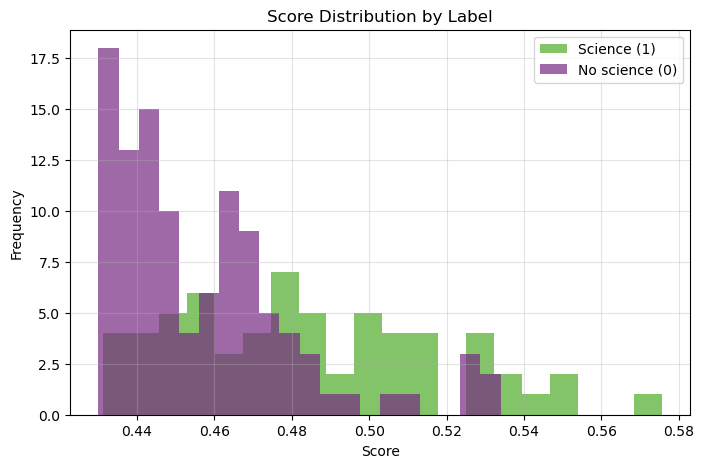

In [13]:
plt.figure(figsize=(8,5))
plt.hist(
    df_etiquetado[df_etiquetado["valido_ciencia"]==1]["score"], 
    bins=20, alpha=0.7, label="Science (1)", color="#4dac26"
)
plt.hist(
    df_etiquetado[df_etiquetado["valido_ciencia"]==0]["score"], 
    bins=20, alpha=0.7, label="No science (0)", color="#762a83"
)
plt.grid(True, alpha=0.35)
plt.xlabel("Score")
plt.ylabel("Frequency")
plt.legend()
plt.title("Score Distribution by Label")
plt.show()

In [14]:
plt.figure(figsize=(8,5))
plt.hist(
    df_etiquetado[df_etiquetado["valido_ciencia"]==1]["score"], 
    bins=20, alpha=0.7, label="Science (1)", color="#4dac26"
)
plt.hist(
    df_etiquetado[df_etiquetado["valido_ciencia"]==0]["score"], 
    bins=20, alpha=0.7, label="No science (0)", color="#762a83"
)
plt.grid(True, alpha=0.35)
plt.xlabel("Score")
plt.ylabel("Frequency")
plt.legend()
plt.title("Score Distribution by Label")

# Guardar la figura
plt.tight_layout()
plt.savefig("../reports/articulo_revista/figures/distribucion_scores.png", dpi=300)
plt.close()

# 9. Encontrar el mejor umbral

In [7]:
umbrales = np.linspace(0, 1, 1001)
mejor_umbral = None
mejor_acc = 0
resultados = []

for u in umbrales:
    pred = (df_etiquetado["score"] >= u).astype(int)
    acc = (pred == df_etiquetado["valido_ciencia"]).mean()
    resultados.append((u, acc))
    if acc > mejor_acc:
        mejor_acc = acc
        mejor_umbral = u

print(f"Mejor umbral: {mejor_umbral:.2f} con accuracy = {mejor_acc:.3f}")

Mejor umbral: 0.47 con accuracy = 0.741


In [8]:
umbrales

array([0.   , 0.001, 0.002, ..., 0.998, 0.999, 1.   ])

# 10. Graficar accuracy por umbral

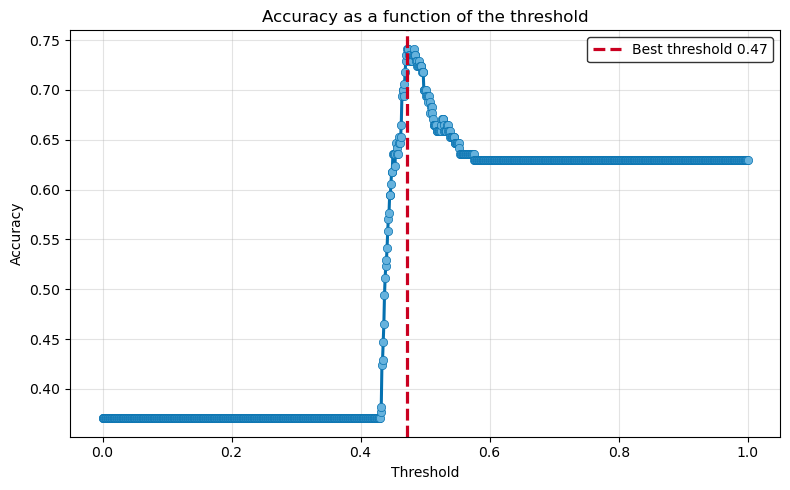

In [9]:
color_line = "#0571b0"           # Azul principal para la curva
color_threshold = "#ca0020"      # Rojo para la línea vertical
color_fill = "#66b2dd"           # Azul aclarado para el interior del marcador

thresholds = [r[0] for r in resultados]
accuracies = [r[1] for r in resultados]

plt.figure(figsize=(8,5))

# Línea con markers personalizados
plt.plot(
    thresholds,
    accuracies,
    marker="o",
    linewidth=2.2,
    markersize=6,
    color=color_line,
    markerfacecolor=color_fill,    # Relleno más claro
    markeredgecolor=color_line,    # Borde azul saturado
    markeredgewidth=0.5
)

# Línea vertical del mejor umbral
plt.axvline(
    mejor_umbral,
    color=color_threshold,
    linestyle="--",
    linewidth=2.3,
    label=f"Best threshold {mejor_umbral:.2f}"
)

plt.xlabel("Threshold")
plt.ylabel("Accuracy")
plt.title("Accuracy as a function of the threshold")

plt.grid(True, alpha=0.35)
plt.legend(frameon=True, facecolor="white", edgecolor="black")
plt.tight_layout()
plt.show()

In [10]:
color_line = "#0571b0"           # Azul principal para la curva
color_threshold = "#ca0020"      # Rojo para la línea vertical
color_fill = "#66b2dd"           # Azul aclarado para el interior del marcador

thresholds = [r[0] for r in resultados]
accuracies = [r[1] for r in resultados]

plt.figure(figsize=(8,5))

# Línea con markers personalizados
plt.plot(
    thresholds,
    accuracies,
    marker="o",
    linewidth=2.2,
    markersize=6,
    color=color_line,
    markerfacecolor=color_fill,    # Relleno más claro
    markeredgecolor=color_line,    # Borde azul saturado
    markeredgewidth=0.5
)

# Línea vertical del mejor umbral
plt.axvline(
    mejor_umbral,
    color=color_threshold,
    linestyle="--",
    linewidth=2.3,
    label=f"Best threshold {mejor_umbral:.2f}"
)

plt.xlabel("Threshold")
plt.ylabel("Accuracy")
plt.title("Accuracy as a function of the threshold")

plt.grid(True, alpha=0.35)
plt.legend(frameon=True, facecolor="white", edgecolor="black")
plt.tight_layout()
plt.savefig("../reports/articulo_revista/figures/accuracy_umbral.png", dpi=300)
plt.close()